# 気象データアナリスト養成講座
# PythonによるGPVのハンドリング

PythonでGRIB2形式のGPVデータをデコードし、気象要素の変換計算などを経て、欲しいデータを取得する方法を解説します。<br>
やり方はいくつかありますが、ここではPythonモジュール`xarray`と`wxparams`を使う方法を紹介します。<br>
また`xarray`でGPVデータを読み込むために、GRIB2形式からNetCDF形式へと変換する`wgrib2`ソフトウェアについても紹介します。<br>

---
### 目次
1. [Python上でwgrib2を実行する](#1.-Python上でwgrib2を実行する)
1. [Pythonモジュールxarrayを使ってGPVを読み込む](#2.-Pythonモジュールxarrayを使ってGPVを読み込む)
1. [GPVデータ処理演習](#3.-GPVデータ処理演習)

---

## 1. Python上でwgrib2を実行する

GRIB2形式のGPVデータをデコードするソフトウェア`wgrib2`をPython上で実行する方法を紹介します。

通常`wgrib2`は、MacのターミナルやWindowsのコマンドプロンプトで、コマンドを手入力して実行します。<br>
これと同じことをPythonで実行する場合、`subprocess`モジュールを使います。<br>
ディレクトリやファイルの操作をするのに便利な`os`モジュールとともに、まずはモジュールの読み込みをしましょう。<br>

以下のセルを実行して下さい。<br>

In [20]:
import os
import subprocess

`subprocess`を使ってコマンドラインのコマンドを実行するには、以下のようにコードを書きます。<br>
- ダブルクォーテーションで囲った部分に、実行したいコマンドを記述します
- それ以外の部分は、おまじないだと思ってそのまま使って下さい

まず`wgrib2`のバージョン情報を出力してみましょう。<br>
インストール確認でも実行した以下のコマンドを、ダブルクォーテーションで囲った部分に記述して実行します。<br>

```
(Macの場合)
    wgrib2 --version

(Windowsの場合)
    c:\wgrib2\wgrib2 --version
```

In [22]:
#--subprocessでコマンドを実行
# Macの場合
rc = subprocess.run("wgrib2 --version",
                    shell=True,
                    stdout=subprocess.PIPE,
                    stderr=subprocess.PIPE,
                    universal_newlines=True)

# # Windowsの場合
# rc = subprocess.run("c:\wgrib2\wgrib2 --version",
#                     shell=True,
#                     stdout=subprocess.PIPE,
#                     stderr=subprocess.PIPE,
#                     universal_newlines=True)

# 標準出力や標準エラーを出力
for line in rc.stderr.splitlines():
    print(line)
for line in rc.stdout.splitlines():
    print(line)

v3.1.3 10/2023  Wesley Ebisuzaki, Reinoud Bokhorst, John Howard, Jaakko Hyvätti, Dusan Jovic, Daniel Lee, Kristian Nilssen, Karl Pfeiffer, Pablo Romero, Manfred Schwarb, Gregor Schee, Arlindo da Silva, Niklas Sondell, Sam Trahan, George Trojan, Sergey Varlamov


次に、GRIB2形式のGPVデータに記録されている、データ内容の概要（目録）を表示させてみましょう。<br>
概要の情報を表示するには、以下のように`wgrib2`を実行します。<br>
（以下、代表してMacの場合のみ記載）

```
wgrib2 <GRIB2ファイル名>
```

`weather`フォルダにある、数値予報モデルMSMの地上データ（2020/09/05 12zベース、FT=0〜15）の概要を表示させてみましょう。<br>
- ファイル名 ： `Z__C_RJTD_20200905120000_MSM_GPV_Rjp_Lsurf_FH00-15_grib2.bin`<br>

weatherフォルダ内にデータがあることに注意し、ダブルクォーテーションの中にコマンドを記述して実行します。

In [24]:
### 練習問題(1)
# ダブルクォーテーションの間にコマンドを入力して、実行して下さい。

#--subprocessでコマンドを実行
# Macの場合
rc = subprocess.run("wgrib2 weather/Z__C_RJTD_20200905120000_MSM_GPV_Rjp_L-pall_FH00-15_grib2.bin",
                    shell=True,
                    stdout=subprocess.PIPE,
                    stderr=subprocess.PIPE,
                    universal_newlines=True)

# # Windowsの場合
# rc = subprocess.run("c:\wgrib2\wgrib2 weather\Z__C_RJTD_20200905120000_MSM_GPV_Rjp_Lsurf_FH00-15_grib2.bin",
#                     shell=True,
#                     stdout=subprocess.PIPE,
#                     stderr=subprocess.PIPE,
#                     universal_newlines=True)

# 標準出力や標準エラーを出力
for line in rc.stderr.splitlines():
    print(line)
for line in rc.stdout.splitlines():
    print(line)

1.1:0:d=2020090512:HGT:1000 mb:anl:
1.2:0:d=2020090512:UGRD:1000 mb:anl:
1.3:0:d=2020090512:VGRD:1000 mb:anl:
1.4:0:d=2020090512:TMP:1000 mb:anl:
1.5:0:d=2020090512:VVEL:1000 mb:anl:
1.6:0:d=2020090512:RH:1000 mb:anl:
1.7:0:d=2020090512:HGT:975 mb:anl:
1.8:0:d=2020090512:UGRD:975 mb:anl:
1.9:0:d=2020090512:VGRD:975 mb:anl:
1.10:0:d=2020090512:TMP:975 mb:anl:
1.11:0:d=2020090512:VVEL:975 mb:anl:
1.12:0:d=2020090512:RH:975 mb:anl:
1.13:0:d=2020090512:HGT:950 mb:anl:
1.14:0:d=2020090512:UGRD:950 mb:anl:
1.15:0:d=2020090512:VGRD:950 mb:anl:
1.16:0:d=2020090512:TMP:950 mb:anl:
1.17:0:d=2020090512:VVEL:950 mb:anl:
1.18:0:d=2020090512:RH:950 mb:anl:
1.19:0:d=2020090512:HGT:925 mb:anl:
1.20:0:d=2020090512:UGRD:925 mb:anl:
1.21:0:d=2020090512:VGRD:925 mb:anl:
1.22:0:d=2020090512:TMP:925 mb:anl:
1.23:0:d=2020090512:VVEL:925 mb:anl:
1.24:0:d=2020090512:RH:925 mb:anl:
1.25:0:d=2020090512:HGT:900 mb:anl:
1.26:0:d=2020090512:UGRD:900 mb:anl:
1.27:0:d=2020090512:VGRD:900 mb:anl:
1.28:0:d=2020090512:T

この出力は、1行あたり1種類のデータの概要を表しています。各行はコロン「:」区切りで、以下のような内容となっています<br>

```
<行番号>:0:d=<初期時刻>:<気象要素>:<高度>:<予報対象時刻>:
```

全部で190行ありますので、190種のデータが重なっていることになります。また気象要素は以下の通りです。<br>

|コード|気象要素名|
|---|---|
|PRMSL|海面気圧|
|PRES|地上気圧|
|UGRD|風のU成分(東西風)|
|VGRD|風のV成分(南北風)|
|TMP|気温|
|RH|相対湿度|
|LCDC|下層雲量|
|MCDC|中層雲量|
|HCDC|上層雲量|
|TCDC|全雲量|
|APCP|前1時間積算降水量|
|DSWRF|前1時間平均日射量|

なお、より詳しいデータ内容を表示させるには`-V`オプションをつけて以下のように実行します。
```
wgrib2 <GRIB2ファイル名> -V
```
気象要素名やその単位、座標の情報などを見ることができますので、試してみて下さい。

<br><br>
次は`wgrib2`の`-match`オプションを使って、気温（`TMP`）のみを選択し、概要を表示してみましょう。<br>
`-match`オプションでは、指定した文字列を含むデータの種類（行）のみに絞って出力することができます。
```
wgrib2 <GRIB2ファイル名> -match <文字列>
```

オプションが増えるとコマンドが長くなりますので、下記のように適宜変数を活用するとコードが見やすくなります。<br>
ここで`f文字列`と呼ばれる機能を使うと、変数からコマンドの文字列を作成することができます。

In [26]:
#--subprocessでコマンドを実行
# wgrib2コマンドを変数に入れる
wgrib2 = "wgrib2" #---Mac用
# wgrib2 = "c:\wgrib2\wgrib2" #---Windows用

# ファイルへのパス
gpvpath = os.path.join("weather", "Z__C_RJTD_20200905120000_MSM_GPV_Rjp_L-pall_FH00-15_grib2.bin")

# wgrib2に与えるオプション
option = '-match TMP'

# f文字列を使って作成するコマンドをprintしてみる
print("実行するコマンド")
print(f"{wgrib2} {gpvpath} {option}")
print("")

# コマンドを実行
rc = subprocess.run(f"{wgrib2} {option} {gpvpath}",
                    shell=True,
                    stdout=subprocess.PIPE,
                    stderr=subprocess.PIPE,
                    universal_newlines=True)

# 標準出力や標準エラーを出力
for line in rc.stderr.splitlines():
    print(line)
for line in rc.stdout.splitlines():
    print(line)

実行するコマンド
wgrib2 weather/Z__C_RJTD_20200905120000_MSM_GPV_Rjp_L-pall_FH00-15_grib2.bin -match TMP

1.4:0:d=2020090512:TMP:1000 mb:anl:
1.10:0:d=2020090512:TMP:975 mb:anl:
1.16:0:d=2020090512:TMP:950 mb:anl:
1.22:0:d=2020090512:TMP:925 mb:anl:
1.28:0:d=2020090512:TMP:900 mb:anl:
1.34:0:d=2020090512:TMP:850 mb:anl:
1.40:0:d=2020090512:TMP:800 mb:anl:
1.46:0:d=2020090512:TMP:700 mb:anl:
1.52:0:d=2020090512:TMP:600 mb:anl:
1.58:0:d=2020090512:TMP:500 mb:anl:
1.64:0:d=2020090512:TMP:400 mb:anl:
1.70:0:d=2020090512:TMP:300 mb:anl:
1.76:0:d=2020090512:TMP:250 mb:anl:
1.81:0:d=2020090512:TMP:200 mb:anl:
1.86:0:d=2020090512:TMP:150 mb:anl:
1.91:0:d=2020090512:TMP:100 mb:anl:
1.96:0:d=2020090512:TMP:1000 mb:3 hour fcst:
1.102:0:d=2020090512:TMP:975 mb:3 hour fcst:
1.108:0:d=2020090512:TMP:950 mb:3 hour fcst:
1.114:0:d=2020090512:TMP:925 mb:3 hour fcst:
1.120:0:d=2020090512:TMP:900 mb:3 hour fcst:
1.126:0:d=2020090512:TMP:850 mb:3 hour fcst:
1.132:0:d=2020090512:TMP:800 mb:3 hour fcst:
1.138:0:d=2

<br>更に、予報対象時刻をFT=1（1時間後）に絞ってみましょう。`-match`オプションは複数重ねて使うことができます。
```
wgrib2 <GRIB2ファイル名> -match <文字列1> -match <文字列2>
```

In [5]:
### 練習問題(2)
# wgrib2に与えるオプションを入力して、実行して下さい。

#--subprocessでコマンドを実行
# wgrib2に与えるオプション
option = '-match TMP -match ":1 hour fcst:"'

# コマンドを実行
rc = subprocess.run(f"{wgrib2} {gpvpath} {option}",
                    shell=True,
                    stdout=subprocess.PIPE,
                    stderr=subprocess.PIPE,
                    universal_newlines=True)

# 標準出力や標準エラーを出力
for line in rc.stderr.splitlines():
    print(line)
for line in rc.stdout.splitlines():
    print(line)

1.15:0:d=2020090512:TMP:1.5 m above ground:1 hour fcst:


<br>
だいぶ慣れてきましたでしょうか？<br>

では最後に、GRIB2形式のGPVデータを、別の形式に変換してみましょう。<br>
ここではCSV形式で書き出す方法と、NetCDF形式に変換する方法を紹介します。
```
（CSV形式で出力）
    wgrib2 <GRIB2ファイル> -csv <出力するCSVファイル名>

（NetCDF形式で出力）
    wgrib2 <GRIB2ファイル> -netcdf <出力するNetCDFファイル名>
```

CSV形式で書き出すと、ファイルサイズが大きくなりやすい点に注意が必要です。<br>
先ほどの『FT=1の気温』のように、1種類のデータに絞ってCSV形式に書き出しただけでも、ファイルサイズが約45MBほどになります。<br>
このため、CSV形式で書き出す場合は、必ず`-match`オプションでデータ数を絞った上で行って下さい。

NetCDF形式の場合は、GRIB2形式よりはファイルサイズが大きくなりますが、一般には丸ごとNetCDFに変換しても大丈夫です。<br>
ここでは`GRIB2ファイル名.nc`という命名則で、`weather`フォルダ以下にNetCDFファイルを作るようにします。<br>
変数を活用して、ダブルクォーテーションの中にコマンドを記述し、セルを実行して下さい。<br>

In [6]:
### 練習問題(3)
# 変数を活用してダブルクォーテーションの中にコマンドを記述し、実行して下さい。

#--subprocessでコマンドを実行
ncpath = gpvpath + ".nc"

rc = subprocess.run(f"{wgrib2} {gpvpath} -netcdf {ncpath}",
                    shell=True,
                    stdout=subprocess.PIPE,
                    stderr=subprocess.PIPE,
                    universal_newlines=True)

# 標準出力や標準エラーを出力
for line in rc.stderr.splitlines():
    print(line)
for line in rc.stdout.splitlines():
    print(line)

1.1:0:d=2020090512:PRMSL:mean sea level:anl:
1.2:0:d=2020090512:PRES:surface:anl:
1.3:0:d=2020090512:UGRD:10 m above ground:anl:
1.4:0:d=2020090512:VGRD:10 m above ground:anl:
1.5:0:d=2020090512:TMP:1.5 m above ground:anl:
1.6:0:d=2020090512:RH:1.5 m above ground:anl:
1.7:0:d=2020090512:LCDC:surface:anl:
1.8:0:d=2020090512:MCDC:surface:anl:
1.9:0:d=2020090512:HCDC:surface:anl:
1.10:0:d=2020090512:TCDC:surface:anl:
1.11:0:d=2020090512:PRMSL:mean sea level:1 hour fcst:
1.12:0:d=2020090512:PRES:surface:1 hour fcst:
1.13:0:d=2020090512:UGRD:10 m above ground:1 hour fcst:
1.14:0:d=2020090512:VGRD:10 m above ground:1 hour fcst:
1.15:0:d=2020090512:TMP:1.5 m above ground:1 hour fcst:
1.16:0:d=2020090512:RH:1.5 m above ground:1 hour fcst:
1.17:0:d=2020090512:LCDC:surface:1 hour fcst:
1.18:0:d=2020090512:MCDC:surface:1 hour fcst:
1.19:0:d=2020090512:HCDC:surface:1 hour fcst:
1.20:0:d=2020090512:TCDC:surface:1 hour fcst:
1.21:0:d=2020090512:APCP:surface:0-1 hour acc fcst:
1.22:0:d=2020090512:DSW

`weather`フォルダを開き、NetCDFファイルが作成されていることを確認して下さい。<br>

ここでファイルサイズを見て下さい。元々のGRIB2が約70MB、NetCDFが約180MBほどではないでしょうか。<br>
一般にはGRIB2の方が圧縮性が高いため、ファイルサイズも小さくなっています。<br>

以上で、Python上で`wgrib2`を実行し、GRIB2のGPVデータをNetCDFへ変換することができました。<br>
[目次へ戻る](#目次)

---

## 2. Pythonモジュールxarrayを使ってGPVを読み込む

NetCDF形式のファイルの読み込みには、`xarray`モジュールを利用します。<br>
また読み込んだデータを扱う際には`numpy`も利用します。<br>

まずはモジュールのimportから行います。以下のセルを実行して下さい。<br>

In [7]:
import os
import xarray as xr
import numpy as np

`xr.open_mfdataset`関数を使ってNetCDFファイルを開きます。<br>
細かい話ですが、この段階では開くだけで、まだ値は読み込んでいません。<br>
以下のセルを実行するだけで、open完了です。<br>

In [8]:
#--第1章で作成したNetCDF形式のGPVファイルを開く
ncpath = os.path.join("weather", "Z__C_RJTD_20200905120000_MSM_GPV_Rjp_Lsurf_FH00-15_grib2.bin.nc")
ds = xr.open_mfdataset(ncpath)

変数dsには、GPVの中身についてのヘッダー情報が入っています。<br>
print関数を使うか、もしくは変数dsだけ記述して実行することで、ヘッダ情報を確認できます。<br>

In [9]:
#--ヘッダ情報の確認
ds
# print(ds)

<xarray.Dataset>
Dimensions:              (latitude: 505, longitude: 481, time: 16)
Coordinates:
  * latitude             (latitude) float64 22.4 22.45 22.5 ... 47.5 47.55 47.6
  * longitude            (longitude) float64 120.0 120.1 120.1 ... 149.9 150.0
  * time                 (time) datetime64[ns] 2020-09-05T12:00:00 ... 2020-0...
Data variables:
    PRMSL_meansealevel   (time, latitude, longitude) float32 dask.array<chunksize=(16, 505, 481), meta=np.ndarray>
    PRES_surface         (time, latitude, longitude) float32 dask.array<chunksize=(16, 505, 481), meta=np.ndarray>
    UGRD_10maboveground  (time, latitude, longitude) float32 dask.array<chunksize=(16, 505, 481), meta=np.ndarray>
    VGRD_10maboveground  (time, latitude, longitude) float32 dask.array<chunksize=(16, 505, 481), meta=np.ndarray>
    TMP_1D5maboveground  (time, latitude, longitude) float32 dask.array<chunksize=(16, 505, 481), meta=np.ndarray>
    RH_1D5maboveground   (time, latitude, longitude) float32 dask.array<chunksize=(16, 505, 481), meta=np.ndarray>
    LCDC_surface         (time, latitude, longitude) float32 dask.array<chunksize=(16, 505, 481), meta=np.ndarray>
    MCDC_surface         (time, latitude, longitude) float32 dask.array<chunksize=(16, 505, 481), meta=np.ndarray>
    HCDC_surface         (time, latitude, longitude) float32 dask.array<chunksize=(16, 505, 481), meta=np.ndarray>
    TCDC_surface         (time, latitude, longitude) float32 dask.array<chunksize=(16, 505, 481), meta=np.ndarray>
    APCP_surface         (time, latitude, longitude) float32 dask.array<chunksize=(16, 505, 481), meta=np.ndarray>
    DSWRF_surface        (time, latitude, longitude) float32 dask.array<chunksize=(16, 505, 481), meta=np.ndarray>
Attributes:
    Conventions:          COARDS
    History:              created by wgrib2
    GRIB2_grid_template:  0

気象要素だけをリストで書き出すには以下のようにします。

In [10]:
# データの要素名を出力
list(ds.data_vars)

['PRMSL_meansealevel',
 'PRES_surface',
 'UGRD_10maboveground',
 'VGRD_10maboveground',
 'TMP_1D5maboveground',
 'RH_1D5maboveground',
 'LCDC_surface',
 'MCDC_surface',
 'HCDC_surface',
 'TCDC_surface',
 'APCP_surface',
 'DSWRF_surface']

要素名は`<気象要素_高度>`という形になっています。

ではこの中から気温を選択してみましょう。気温は`TMP`という略称が使われています。<br>
また高度の情報である`1D5maboveground`は`地上1.5m`の意味です。<br>

In [11]:
ds['TMP_1D5maboveground']

<xarray.DataArray 'TMP_1D5maboveground' (time: 16, latitude: 505, longitude: 481)>
dask.array<open_dataset-3e04d5654ca67cd55bd28e9ee22f9a93TMP_1D5maboveground, shape=(16, 505, 481), dtype=float32, chunksize=(16, 505, 481), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 22.4 22.45 22.5 22.55 ... 47.5 47.55 47.6
  * longitude  (longitude) float64 120.0 120.1 120.1 120.2 ... 149.9 149.9 150.0
  * time       (time) datetime64[ns] 2020-09-05T12:00:00 ... 2020-09-06T03:00:00
Attributes:
    short_name:  TMP_1D5maboveground
    long_name:   Temperature
    level:       1.5 m above ground
    units:       K

何やら気温のデータに関するヘッダー情報のようなものが表示されました。<br>
これらの情報は、以下のようにしてもう少し細かく分解できます。<br>

In [12]:
# 気象要素名と単位を表示
print("データ名：", ds['TMP_1D5maboveground'].long_name)
print("単位：", ds['TMP_1D5maboveground'].units)

データ名： Temperature
単位： K


気温の値そのものには、以下のようにしてアクセスできます。

In [13]:
# 気温の値を表示
temp = ds['TMP_1D5maboveground'].values
print(temp.shape)
temp

(16, 505, 481)


array([[[302.0578 , 302.03436, 302.01874, ..., 302.08905, 302.04218,
         302.0031 ],
        [302.02655, 301.9875 , 301.9406 , ..., 302.0656 , 302.01874,
         301.9875 ],
        [301.9953 , 301.9406 , 301.8781 , ..., 302.05   , 302.01093,
         301.97968],
        ...,
        [283.0031 , 282.925  , 282.9328 , ..., 286.76874, 286.76874,
         286.76093],
        [282.88593, 282.78436, 282.76093, ..., 286.8078 , 286.8    ,
         286.79218],
        [283.02655, 282.8703 , 282.8156 , ..., 286.83124, 286.82343,
         286.82343]],

       [[301.89423, 301.80048, 301.6911 , ..., 302.04266, 302.0114 ,
         301.98798],
        [301.86298, 301.7458 , 301.6208 , ..., 302.03485, 301.9958 ,
         301.97235],
        [301.8239 , 301.6911 , 301.53485, ..., 302.01923, 301.98798,
         301.95673],
        ...,
        [282.53485, 282.34735, 282.33954, ..., 286.83954, 286.8239 ,
         286.8239 ],
        [282.4411 , 282.2458 , 282.1989 , ..., 286.8708 , 286.86298,
   

出力を見ますと、(time, latitude, longitude)の順番になったnumpy.ndarray形式で値を取得できたことがわかります。<br>

- 時間ステップ(FT) = 0〜15
- 緯度方向のグリッド数 = 505
- 経度方向のグリッド数 = 481

また、気温の値は、そのオーダーからも絶対温度[K]であることがわかります。<br>
これで気象要素を代表して気温の値を取り出すことができました。<br>

では次は地上気圧のデータを取得してみましょう。<br>

In [14]:
### 練習問題(4)
# 地上気圧のデータをnumpy.ndarray型で取得して下さい
press = ds['PRES_surface'].values
print(press.shape)
press

(16, 505, 481)


array([[[100515.46 , 100515.46 , 100515.46 , ..., 101227.96 ,
         101227.96 , 101227.96 ],
        [100515.46 , 100515.46 , 100515.46 , ..., 101227.96 ,
         101227.96 , 101227.96 ],
        [100515.46 , 100515.46 , 100515.46 , ..., 101227.96 ,
         101227.96 , 101227.96 ],
        ...,
        [ 87502.96 ,  87427.96 ,  87565.46 , ..., 101927.96 ,
         101927.96 , 101927.96 ],
        [ 87340.46 ,  87065.46 ,  87165.46 , ..., 101927.96 ,
         101927.96 , 101927.96 ],
        [ 87402.96 ,  87077.96 ,  87102.96 , ..., 101927.96 ,
         101927.96 , 101927.96 ]],

       [[100562.16 , 100562.16 , 100562.16 , ..., 101199.66 ,
         101199.66 , 101199.66 ],
        [100562.16 , 100562.16 , 100562.16 , ..., 101199.66 ,
         101199.66 , 101199.66 ],
        [100562.16 , 100562.16 , 100562.16 , ..., 101212.16 ,
         101212.16 , 101212.16 ],
        ...,
        [ 87524.66 ,  87449.66 ,  87587.16 , ..., 101899.66 ,
         101912.16 , 101912.16 ],
        [ 87

ここまでは1つの気象要素のデータを、全ての時間・緯度・経度について配列で取り出す処理を行いました。<br>

今度は、緯度経度を指定して時系列データを取り出してみます。selメソッドを使って、たった1行のコードでできてしまいます。<br>
以下のようにして、北緯35度・東経140度の気温の値を取り出してみましょう。<br>

In [15]:
#--北緯35度・東経140度の時系列データを取得
# とりあえず緯度経度を指定した状態を確認する場合
# ds.sel(latitude=35, longitude=140)

# 緯度経度を指定して気温の値を取り出す
ts_temp = ds.sel(latitude=35, longitude=140)['TMP_1D5maboveground'].values
ts_temp

array([300.13593, 300.09735, 300.31308, 300.9329 , 301.23544, 301.71756,
       301.7408 , 301.71555, 301.74518, 301.79312, 301.6907 , 301.31134,
       300.7464 , 300.56757, 301.1153 , 301.3836 ], dtype=float32)

ここで北緯35度・東経140度は、あえて格子点の座標と一致させています。その場合は上記のコードで値を取得できます。<br>

しかし通常は、格子点の座標に関わらず任意の緯度経度で値を取得したい場合が多いです<br>
その場合は`method`オプションを使うことで最寄り格子点の値を取得することができます。<br>

```
ds.sel(latitude=任意の緯度, longitude=任意の経度, method="nearest")
```

さらに最寄り格子点ではなく、線形内挿した値を取得することもできます。その場合は`interp`メソッドを使用します。

```
ds.interp(latitude=任意の緯度, longitude=任意の経度, method="linear")
```

それでは次は、北緯26.89度・東経125.21度の地上気圧の時系列データを取得してみましょう。<br>

In [16]:
### 練習問題(5)
# 北緯26.89度・東経125.21度の地上気圧の時系列データを、xarrayで取得する 

# 最寄り格子点を取る場合
# ts_press = ds.sel(latitude=26.89, longitude=125.21, method="nearest")['PRES_surface'].values
# ts_press

# 線形内挿する場合
ts_press = ds.interp(latitude=26.89, longitude=125.21, method="linear")['PRES_surface'].values
ts_press

array([100172.5609375, 100232.65625  , 100176.3359375, 100101.4984375,
       100044.1484375,  99961.953125 ,  99888.703125 ,  99826.3984375,
        99787.0453125,  99784.18125  ,  99783.6015625,  99779.6171875,
        99762.359375 ,  99773.49375  ,  99757.9921875,  99718.5625   ])

### xarray追加コンテンツ
以上がxarrayの最も基本的な使い方ですが、他にも様々な処理が可能です。

#### データを全て読み込む
前述のように`xr.open_mfdataset`関数ではヘッダー情報を読み込むだけで、まだ値は読み込んでいない状態です。<br>
そこで`load`メソッドを使って、明示的に値を全部読み込んでメモリに乗せてみます。

In [17]:
# 値を全部読み込んでしまう
ds.load()

<xarray.Dataset>
Dimensions:              (latitude: 505, longitude: 481, time: 16)
Coordinates:
  * latitude             (latitude) float64 22.4 22.45 22.5 ... 47.5 47.55 47.6
  * longitude            (longitude) float64 120.0 120.1 120.1 ... 149.9 150.0
  * time                 (time) datetime64[ns] 2020-09-05T12:00:00 ... 2020-0...
Data variables:
    PRMSL_meansealevel   (time, latitude, longitude) float32 1.005e+05 ... 1....
    PRES_surface         (time, latitude, longitude) float32 1.005e+05 ... 1....
    UGRD_10maboveground  (time, latitude, longitude) float32 -0.8853 ... 3.192
    VGRD_10maboveground  (time, latitude, longitude) float32 -9.317 ... 4.171
    TMP_1D5maboveground  (time, latitude, longitude) float32 302.1 ... 287.5
    RH_1D5maboveground   (time, latitude, longitude) float32 73.54 ... 99.05
    LCDC_surface         (time, latitude, longitude) float32 0.7812 ... 100.0
    MCDC_surface         (time, latitude, longitude) float32 15.62 ... 47.12
    HCDC_surface         (time, latitude, longitude) float32 0.0 0.0 ... 25.98
    TCDC_surface         (time, latitude, longitude) float32 15.62 ... 100.0
    APCP_surface         (time, latitude, longitude) float32 nan nan ... 0.0 0.0
    DSWRF_surface        (time, latitude, longitude) float32 nan nan ... 102.3
Attributes:
    Conventions:          COARDS
    History:              created by wgrib2
    GRIB2_grid_template:  0

#### スライシング
`xarray`の強みの1つに、スライシングの多機能性があげられます。<br>
例えば`sel`メソッドを使うと、座標軸（ここでは時間・緯度・経度）方向にデータの絞り込みをすることができます。<br>
これは、`Pandas`の`loc`に相当する機能と言えます。<br>

例えば時間軸については、下記のようにして予報時刻を絞ることができます。

In [18]:
# スライシング
# selの場合（各軸の実際の値で指定）
ds.sel(time=slice("2020-09-05T15:00:00","2020-09-05T21:00:00"))

# 時間軸を絞った上で、気温の値を取得する
# ds.sel(time=slice("2020-09-05T15:00:00","2020-09-05T21:00:00"))["TMP_1D5maboveground"].values

<xarray.Dataset>
Dimensions:              (latitude: 505, longitude: 481, time: 7)
Coordinates:
  * latitude             (latitude) float64 22.4 22.45 22.5 ... 47.5 47.55 47.6
  * longitude            (longitude) float64 120.0 120.1 120.1 ... 149.9 150.0
  * time                 (time) datetime64[ns] 2020-09-05T15:00:00 ... 2020-0...
Data variables:
    PRMSL_meansealevel   (time, latitude, longitude) float32 1.006e+05 ... 1....
    PRES_surface         (time, latitude, longitude) float32 1.006e+05 ... 1....
    UGRD_10maboveground  (time, latitude, longitude) float32 -1.608 ... 3.913
    VGRD_10maboveground  (time, latitude, longitude) float32 -7.987 ... 6.299
    TMP_1D5maboveground  (time, latitude, longitude) float32 301.4 ... 287.8
    RH_1D5maboveground   (time, latitude, longitude) float32 73.08 ... 98.25
    LCDC_surface         (time, latitude, longitude) float32 0.0 0.0 ... 100.0
    MCDC_surface         (time, latitude, longitude) float32 5.42 ... 44.38
    HCDC_surface         (time, latitude, longitude) float32 0.0 0.0 ... 16.41
    TCDC_surface         (time, latitude, longitude) float32 5.42 ... 100.0
    APCP_surface         (time, latitude, longitude) float32 0.0 0.0 ... 0.0
    DSWRF_surface        (time, latitude, longitude) float32 0.0 0.0 ... 10.59
Attributes:
    Conventions:          COARDS
    History:              created by wgrib2
    GRIB2_grid_template:  0

`isel`というメソッドもあり、`iloc`のようにインデックス番号で絞ることもできます。

In [19]:
# iselの場合（インデックス番号で指定）
ds.isel(time=slice(3,10))

<xarray.Dataset>
Dimensions:              (latitude: 505, longitude: 481, time: 7)
Coordinates:
  * latitude             (latitude) float64 22.4 22.45 22.5 ... 47.5 47.55 47.6
  * longitude            (longitude) float64 120.0 120.1 120.1 ... 149.9 150.0
  * time                 (time) datetime64[ns] 2020-09-05T15:00:00 ... 2020-0...
Data variables:
    PRMSL_meansealevel   (time, latitude, longitude) float32 1.006e+05 ... 1....
    PRES_surface         (time, latitude, longitude) float32 1.006e+05 ... 1....
    UGRD_10maboveground  (time, latitude, longitude) float32 -1.608 ... 3.913
    VGRD_10maboveground  (time, latitude, longitude) float32 -7.987 ... 6.299
    TMP_1D5maboveground  (time, latitude, longitude) float32 301.4 ... 287.8
    RH_1D5maboveground   (time, latitude, longitude) float32 73.08 ... 98.25
    LCDC_surface         (time, latitude, longitude) float32 0.0 0.0 ... 100.0
    MCDC_surface         (time, latitude, longitude) float32 5.42 ... 44.38
    HCDC_surface         (time, latitude, longitude) float32 0.0 0.0 ... 16.41
    TCDC_surface         (time, latitude, longitude) float32 5.42 ... 100.0
    APCP_surface         (time, latitude, longitude) float32 0.0 0.0 ... 0.0
    DSWRF_surface        (time, latitude, longitude) float32 0.0 0.0 ... 10.59
Attributes:
    Conventions:          COARDS
    History:              created by wgrib2
    GRIB2_grid_template:  0

スライシングは複数の座標軸について同時に行うこともできます。<br>
今度は緯度経度で範囲を絞ってみます。

In [20]:
# 多次元でもスライシング可能
ds.sel(latitude=slice(25.47, 31.53), longitude=slice(129.11, 135.91))

# 緯度経度を絞った上で、地上気圧の値を取得する
# ds.sel(latitude=slice(25.47, 31.53), longitude=slice(129.11, 135.91))["PRES_surface"].values

<xarray.Dataset>
Dimensions:              (latitude: 121, longitude: 109, time: 16)
Coordinates:
  * latitude             (latitude) float64 25.5 25.55 25.6 ... 31.4 31.45 31.5
  * longitude            (longitude) float64 129.1 129.2 129.2 ... 135.8 135.9
  * time                 (time) datetime64[ns] 2020-09-05T12:00:00 ... 2020-0...
Data variables:
    PRMSL_meansealevel   (time, latitude, longitude) float32 9.861e+04 ... 1....
    PRES_surface         (time, latitude, longitude) float32 9.86e+04 ... 1.0...
    UGRD_10maboveground  (time, latitude, longitude) float32 2.896 ... -13.15
    VGRD_10maboveground  (time, latitude, longitude) float32 -23.16 ... 9.358
    TMP_1D5maboveground  (time, latitude, longitude) float32 301.7 ... 303.3
    RH_1D5maboveground   (time, latitude, longitude) float32 79.93 ... 77.83
    LCDC_surface         (time, latitude, longitude) float32 22.85 ... 28.96
    MCDC_surface         (time, latitude, longitude) float32 73.14 ... 52.54
    HCDC_surface         (time, latitude, longitude) float32 100.0 ... 76.17
    TCDC_surface         (time, latitude, longitude) float32 100.0 ... 77.93
    APCP_surface         (time, latitude, longitude) float32 nan nan ... 0.0625
    DSWRF_surface        (time, latitude, longitude) float32 nan nan ... 401.0
Attributes:
    Conventions:          COARDS
    History:              created by wgrib2
    GRIB2_grid_template:  0

#### 内挿計算
スライシングで座標軸に沿って値を絞ってみましたが、今度は任意の緯度経度や時刻の値を内挿で生成してみます。<br>
`interp`メソッドでは複数の任意の緯度経度、および時刻の値を内挿で作成することができます。

In [21]:
# 任意の内挿（３次元）
ds.interp(latitude=[25.47, 31.53], longitude=[129.11, 135.91], time="2020-09-05T12:30:00")

# 任意の内挿をした上で、地上気圧の値を取得する
# ds.interp(latitude=[25.47, 31.53], longitude=[129.11, 135.91], time="2020-09-05T12:30:00")["PRES_surface"].values

<xarray.Dataset>
Dimensions:              (latitude: 2, longitude: 2)
Coordinates:
  * latitude             (latitude) float64 25.47 31.53
  * longitude            (longitude) float64 129.1 135.9
    time                 datetime64[ns] 2020-09-05T12:30:00
Data variables:
    PRMSL_meansealevel   (latitude, longitude) float64 9.856e+04 ... 1.009e+05
    PRES_surface         (latitude, longitude) float64 9.856e+04 ... 1.009e+05
    UGRD_10maboveground  (latitude, longitude) float64 4.777 -11.71 ... -9.381
    VGRD_10maboveground  (latitude, longitude) float64 -22.88 15.67 -11.0 3.936
    TMP_1D5maboveground  (latitude, longitude) float64 301.7 303.4 300.5 302.8
    RH_1D5maboveground   (latitude, longitude) float64 79.66 74.54 83.94 73.94
    LCDC_surface         (latitude, longitude) float64 26.97 9.366 34.06 29.97
    MCDC_surface         (latitude, longitude) float64 52.04 38.9 33.78 10.84
    HCDC_surface         (latitude, longitude) float64 100.0 97.52 75.03 2.513
    TCDC_surface         (latitude, longitude) float64 100.0 97.52 75.03 29.97
    APCP_surface         (latitude, longitude) float64 nan nan nan nan
    DSWRF_surface        (latitude, longitude) float64 nan nan nan nan
Attributes:
    Conventions:          COARDS
    History:              created by wgrib2
    GRIB2_grid_template:  0

`mean`メソッドや`sum`メソッドで軸方向の計算を行うこともできます。<br>
例えば上記の時間方向の内挿は、`mean`メソッドで以下のように行うこともできます。

In [22]:
# mean関数で内挿結果を確認
ds.isel(time=slice(0,2)).interp(latitude=[25.47, 31.53], longitude=[129.11, 135.91]).mean("time")

# 地上気圧の値を取得する
# ds.isel(time=slice(0,2)).interp(latitude=[25.47, 31.53], longitude=[129.11, 135.91]).mean("time")["PRES_surface"].values

<xarray.Dataset>
Dimensions:              (latitude: 2, longitude: 2)
Coordinates:
  * latitude             (latitude) float64 25.47 31.53
  * longitude            (longitude) float64 129.1 135.9
Data variables:
    PRMSL_meansealevel   (latitude, longitude) float64 9.856e+04 ... 1.009e+05
    PRES_surface         (latitude, longitude) float64 9.856e+04 ... 1.009e+05
    UGRD_10maboveground  (latitude, longitude) float64 4.777 -11.71 ... -9.381
    VGRD_10maboveground  (latitude, longitude) float64 -22.88 15.67 -11.0 3.936
    TMP_1D5maboveground  (latitude, longitude) float64 301.7 303.4 300.5 302.8
    RH_1D5maboveground   (latitude, longitude) float64 79.66 74.54 83.94 73.94
    LCDC_surface         (latitude, longitude) float64 26.97 9.366 34.06 29.97
    MCDC_surface         (latitude, longitude) float64 52.04 38.9 33.78 10.84
    HCDC_surface         (latitude, longitude) float64 100.0 97.52 75.03 2.513
    TCDC_surface         (latitude, longitude) float64 100.0 97.52 75.03 29.97
    APCP_surface         (latitude, longitude) float64 0.5465 0.0 1.234 0.0
    DSWRF_surface        (latitude, longitude) float64 0.0 0.0 0.0 0.0

#### データフレーム化
GPVデータを使う場合、おそらく任意の緯度経度を指定して値を切り出したいことが多いでしょう。<br>
これは`to_dataframe`メソッドで簡単に行うことができます。

In [23]:
# 任意の緯度経度を指定してデータフレーム化
df = ds.interp(latitude=35.69, longitude=139.75, method="linear").to_dataframe()
df

,PRMSL_meansealevel,PRES_surface,UGRD_10maboveground,VGRD_10maboveground,TMP_1D5maboveground,RH_1D5maboveground,LCDC_surface,MCDC_surface,HCDC_surface,TCDC_surface,APCP_surface,DSWRF_surface,latitude,longitude
time,,,,,,,,,,,,,,
2020-09-05 12:00:00,101285.718750,101120.460938,-1.535254,-1.035725,299.714050,87.788231,19.726563,33.398438,6.816406,33.398438,NaN,NaN,35.69,139.75
2020-09-05 13:00:00,101277.906250,101114.656250,-1.583978,-1.208413,299.470789,87.928882,43.125000,23.320313,0.000000,43.125000,0.162500,0.000000,35.69,139.75
2020-09-05 14:00:00,101294.890625,101123.335938,-1.590177,-1.265063,299.280267,88.292206,42.978516,22.207031,3.398437,42.978516,0.056250,0.000000,35.69,139.75
2020-09-05 15:00:00,101287.718750,101121.898438,-1.402236,-1.149267,299.012579,90.217010,40.566406,29.902344,51.269531,51.445312,0.496875,0.000000,35.69,139.75
2020-09-05 16:00:00,101260.343750,101088.648438,-0.996558,-1.250581,298.757318,92.078188,51.376953,30.166016,100.000000,100.000000,1.600000,0.000000,35.69,139.75
2020-09-05 17:00:00,101234.882812,101073.453125,-1.406251,-1.249189,298.664435,91.522769,50.468750,27.060547,78.789062,78.789062,2.831250,0.000000,35.69,139.75
2020-09-05 18:00:00,101223.781250,101058.203125,-1.520646,-1.267693,298.559564,88.188770,36.337891,26.777344,28.994141,37.451172,2.056250,0.000000,35.69,139.75
2020-09-05 19:00:00,101229.953125,101060.898438,-1.414762,-1.169677,298.378046,86.150198,31.396484,20.771484,0.000000,31.396484,1.318750,0.000000,35.69,139.75
2020-09-05 20:00:00,101245.000000,101079.945312,-1.303660,-1.268086,298.257678,85.099167,31.621094,17.236328,0.000000,31.621094,0.834375,0.000000,35.69,139.75


#### グラフ描画
`xarray`にはグラフ作成機能まであります。<br>
例えば任意の緯度経度の、任意の気象要素の時系列グラフは以下のようにして作成することができます。

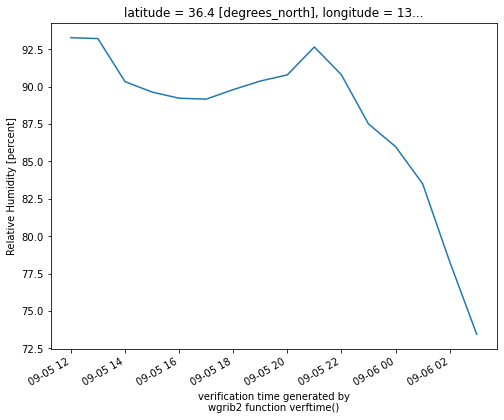

In [24]:
# グラフ描画（時系列グラフ）
ds.sel(latitude=36.4, longitude=139.9, method="nearest")["RH_1D5maboveground"].plot.line(figsize=(8,6))

面的な描画をすることもできます。<br>
例えば以下のようにすると、あるFTの気温（もしくは湿度）を色で描画し、海面気圧を線で描画することができます。

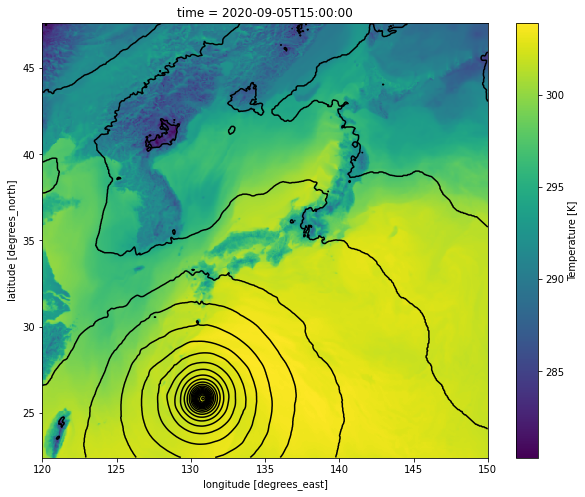

In [25]:
# 平面図
ds.isel(time=3)["TMP_1D5maboveground"].plot(figsize=(10,8))
(ds.isel(time=3)["PRMSL_meansealevel"]/100).plot.contour(levels=30, colors="k")

こうなると海面気圧の等圧線に気圧の値も表示したくなります。<br>
これは`matplotlib`を併用し、以下のようにすることで実現できます。

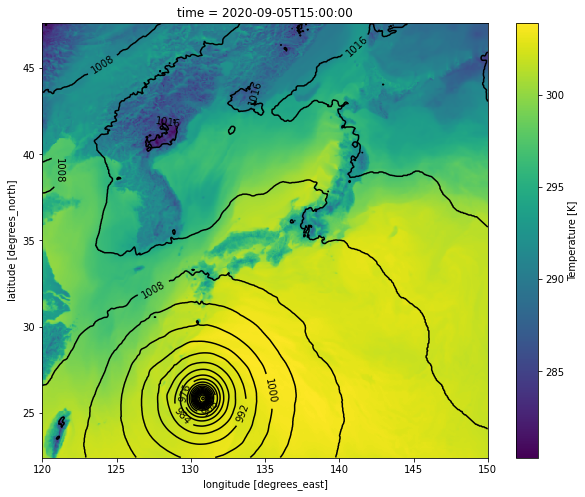

In [26]:
# 平面図（コンターに数値ラベルを付ける）
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(1,1,1)
ds.isel(time=3)["TMP_1D5maboveground"].plot(ax=ax)
cs = (ds.isel(time=3)["PRMSL_meansealevel"]/100).plot.contour(levels=30, colors="k")
ax.clabel(cs,cs.levels[::2],fmt="%d")
plt.show()

海岸線を引くなど、さらに高度な描画をしたい場合は`cartopy`などの専用ライブラリを利用しましょう。

最後に開いたNetCDF形式のGPVファイルを`close`メソッドで閉じておきましょう。<br>
閉じないと必ず問題があるわけではありませんが、エラーが発生してしまう場合もありますので、閉じる方法も覚えておきましょう。

In [27]:
# 最後に、開いたNetCDF形式のGPVファイルを閉じておきます
ds.close()

#### xarray参照サイト
（公式サイト）https://docs.xarray.dev/en/stable/<br>
（Qiita記事）https://qiita.com/fujiisoup/items/0d71995e54055e9708fc

以上で、xarrayを使ってNetCDF形式のGPVデータを処理することができました。<br>
[目次へ戻る](#目次)

---

## 3. GPVデータ処理演習

第1章・第2章で紹介した`wgrib2`と`xarray`、Eラーニングで紹介した`wxparams`を使って、GPVデータ処理の演習を行いましょう。

`weather`フォルダ内にある、数値予報モデルMSMの気圧面データ（2020/09/05 12zベース、FT=0〜15）を使います。
- ファイル名 ： `Z__C_RJTD_20200905120000_MSM_GPV_Rjp_L-pall_FH00-15_grib2.bin`

気圧面データには、地上データにはない気象要素がいくつかあります。

|コード|気象要素名|
|---|---|
|HGT|高度（ジオポテンシャル高度）|
|VVEL|鉛直P速度|

演習を始める前に、カーネルを再起動してゼロからスタートしましょう！

#### 【演習１】
MSM気圧面データのGRIB2をNetCDFに変換し、xarrayで読み込みましょう。<br>
また含まれる気象要素を書き出して下さい。

In [28]:
### ライブラリのimportから開始
### セルは適宜追加して下さい
import os
import subprocess
import numpy as np
import xarray as xr
import wxparams as wx

In [29]:
#--GRIB2 -> NetCDF変換
wgrib2 = "wgrib2" #---Mac用
# wgrib2 = "c:\wgrib2\wgrib2" #---Windows用

grib2_path = os.path.join("weather", "Z__C_RJTD_20200905120000_MSM_GPV_Rjp_L-pall_FH00-15_grib2.bin")
nc_path = grib2_path + ".nc"

rc = subprocess.run(f"{wgrib2} {grib2_path} -netcdf {nc_path}",
                    shell=True,
                    stdout=subprocess.PIPE,
                    stderr=subprocess.PIPE,
                    universal_newlines=True)

In [30]:
#--NetCDF読み込み
ds = xr.open_mfdataset(nc_path)
list(ds.data_vars)

['HGT_1000mb',
 'UGRD_1000mb',
 'VGRD_1000mb',
 'TMP_1000mb',
 'VVEL_1000mb',
 'RH_1000mb',
 'HGT_975mb',
 'UGRD_975mb',
 'VGRD_975mb',
 'TMP_975mb',
 'VVEL_975mb',
 'RH_975mb',
 'HGT_950mb',
 'UGRD_950mb',
 'VGRD_950mb',
 'TMP_950mb',
 'VVEL_950mb',
 'RH_950mb',
 'HGT_925mb',
 'UGRD_925mb',
 'VGRD_925mb',
 'TMP_925mb',
 'VVEL_925mb',
 'RH_925mb',
 'HGT_900mb',
 'UGRD_900mb',
 'VGRD_900mb',
 'TMP_900mb',
 'VVEL_900mb',
 'RH_900mb',
 'HGT_850mb',
 'UGRD_850mb',
 'VGRD_850mb',
 'TMP_850mb',
 'VVEL_850mb',
 'RH_850mb',
 'HGT_800mb',
 'UGRD_800mb',
 'VGRD_800mb',
 'TMP_800mb',
 'VVEL_800mb',
 'RH_800mb',
 'HGT_700mb',
 'UGRD_700mb',
 'VGRD_700mb',
 'TMP_700mb',
 'VVEL_700mb',
 'RH_700mb',
 'HGT_600mb',
 'UGRD_600mb',
 'VGRD_600mb',
 'TMP_600mb',
 'VVEL_600mb',
 'RH_600mb',
 'HGT_500mb',
 'UGRD_500mb',
 'VGRD_500mb',
 'TMP_500mb',
 'VVEL_500mb',
 'RH_500mb',
 'HGT_400mb',
 'UGRD_400mb',
 'VGRD_400mb',
 'TMP_400mb',
 'VVEL_400mb',
 'RH_400mb',
 'HGT_300mb',
 'UGRD_300mb',
 'VGRD_300mb',
 'TM

#### 【演習２】
700hPaの気象要素に絞り、館野（つくば市）の高層観測地点の緯度経度でデータを切り出し、データフレームを作成して下さい。<br>
また、そのデータフレームを使い、湿数（気温と露点温度の差）を計算して下さい。

- 緯度：36.057度
- 経度：140.125度

In [31]:
#--700hPaの気象要素のみに絞ってデータフレーム作成
# 本解答例では最寄り格子点値を取得するが、内挿計算してもよい
loc_lat = 36.057
loc_lon = 140.125

vars_700 = [i for i in list(ds.data_vars) if "700mb" in i]
df_700hPa = ds.sel(latitude=loc_lat, longitude=loc_lon, method="nearest")[vars_700].to_dataframe()

In [32]:
#--気温の単位が[K]なので、[C]に変換
df_700hPa["TMP_700mb"] = df_700hPa["TMP_700mb"] - 273.15
df_700hPa["TD_700mb"] = wx.RH_to_Td(df_700hPa["TMP_700mb"], df_700hPa["RH_700mb"])

#--湿数を計算
df_700hPa["T-TD_700mb"] = df_700hPa["TMP_700mb"] - df_700hPa["TD_700mb"]
df_700hPa

,HGT_700mb,UGRD_700mb,VGRD_700mb,TMP_700mb,VVEL_700mb,RH_700mb,latitude,longitude,TD_700mb,T-TD_700mb
time,,,,,,,,,,
2020-09-05 12:00:00,3174.695801,-9.148849,0.544743,10.363586,0.000000,60.362957,36.1,140.125,3.021256,7.342330
2020-09-05 15:00:00,3170.781006,-7.147934,-0.235741,9.210510,-0.291376,66.568398,36.1,140.125,3.311437,5.899073
2020-09-05 18:00:00,3160.359131,-7.505535,-0.005920,8.309662,0.169014,69.846718,36.1,140.125,3.129826,5.179835
2020-09-05 21:00:00,3163.708252,-5.623283,1.554958,8.722595,-0.099476,50.682594,36.1,140.125,-0.940413,9.663009
2020-09-06 00:00:00,3169.435791,-5.184460,4.062950,8.138489,-0.262300,73.824654,36.1,140.125,3.750105,4.388383
2020-09-06 03:00:00,3164.321777,-3.757175,6.766224,8.737793,-0.719103,81.219688,36.1,140.125,5.698935,3.038858


#### 【演習３】
演習1で読み込んだデータについて、緯度を30度〜40度、経度を135度〜145度に絞って下さい。<br>
また、9月5日13UTCと14UTCの値を内挿計算で求めて下さい。

In [33]:
#--緯度経度の範囲を絞り、時間の内挿計算を行ったxarrayオブジェクトを作成
time_series = ['2020-09-05T13:00:00','2020-09-05T14:00:00']
ds_slice = ds.sel(latitude=slice(30, 40), longitude=slice(135, 145)).interp(time=time_series)
ds_slice

<xarray.Dataset>
Dimensions:      (latitude: 101, longitude: 81, time: 2)
Coordinates:
  * latitude     (latitude) float64 30.0 30.1 30.2 30.3 ... 39.7 39.8 39.9 40.0
  * longitude    (longitude) float64 135.0 135.1 135.2 ... 144.8 144.9 145.0
  * time         (time) datetime64[ns] 2020-09-05T13:00:00 2020-09-05T14:00:00
Data variables: (12/92)
    HGT_1000mb   (time, latitude, longitude) float32 dask.array<chunksize=(2, 101, 81), meta=np.ndarray>
    UGRD_1000mb  (time, latitude, longitude) float32 dask.array<chunksize=(2, 101, 81), meta=np.ndarray>
    VGRD_1000mb  (time, latitude, longitude) float32 dask.array<chunksize=(2, 101, 81), meta=np.ndarray>
    TMP_1000mb   (time, latitude, longitude) float32 dask.array<chunksize=(2, 101, 81), meta=np.ndarray>
    VVEL_1000mb  (time, latitude, longitude) float32 dask.array<chunksize=(2, 101, 81), meta=np.ndarray>
    RH_1000mb    (time, latitude, longitude) float32 dask.array<chunksize=(2, 101, 81), meta=np.ndarray>
    ...           ...
    VVEL_150mb   (time, latitude, longitude) float32 dask.array<chunksize=(2, 101, 81), meta=np.ndarray>
    HGT_100mb    (time, latitude, longitude) float32 dask.array<chunksize=(2, 101, 81), meta=np.ndarray>
    UGRD_100mb   (time, latitude, longitude) float32 dask.array<chunksize=(2, 101, 81), meta=np.ndarray>
    VGRD_100mb   (time, latitude, longitude) float32 dask.array<chunksize=(2, 101, 81), meta=np.ndarray>
    TMP_100mb    (time, latitude, longitude) float32 dask.array<chunksize=(2, 101, 81), meta=np.ndarray>
    VVEL_100mb   (time, latitude, longitude) float32 dask.array<chunksize=(2, 101, 81), meta=np.ndarray>
Attributes:
    Conventions:          COARDS
    History:              created by wgrib2
    GRIB2_grid_template:  0

In [34]:
ds.close()

演習は以上です。<br>
[目次へ戻る](#目次)